In [ ]:
# Bullet Cluster Analysis (UQSH)

Ziel:
Bestimmung der räumlichen Trennung zwischen Gas- und gravitativer Struktur
und Vergleich mit einem strukturabhängigen Feldmodell.

In [ ]:
!pip install pymupdf

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import fitz

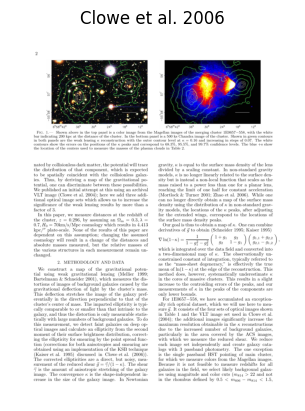

In [14]:
pdf_path = "/content/Bullet Cluster DM.pdf"

doc = fitz.open(pdf_path)
page = doc.load_page(1)

pix = page.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
page_arr = np.array(img)

plt.imshow(page_arr)
plt.axis("off")
plt.title("Clowe et al. 2006")
plt.show()

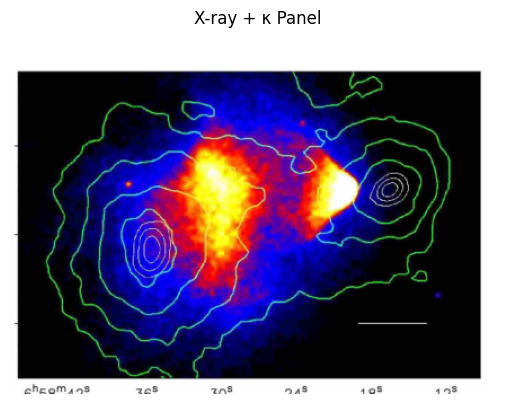

In [15]:
h, w, _ = page_arr.shape

crop = page_arr[int(0.05*h):int(0.40*h), int(0.05*w):int(0.95*w)]

h2, w2, _ = crop.shape

right_panel = crop[int(0.02*h2):int(0.60*h2), int(0.54*w2):int(0.94*w2)]

plt.imshow(right_panel)
plt.axis("off")
plt.title("X-ray + κ Panel")
plt.show()

In [16]:
# manuell bestimmt
bar_len_px = 60

kpc_per_px = 200 / bar_len_px
print("kpc pro Pixel:", kpc_per_px)

kpc pro Pixel: 3.3333333333333335


In [17]:
real_left_kpc = 218.6683445875933
real_right_kpc = 227.63422142504444
real_mean_kpc = 223.15128300631886

compare_real = pd.DataFrame({
    "side": ["left", "right", "mean"],
    "offset_kpc": [real_left_kpc, real_right_kpc, real_mean_kpc]
})

print(compare_real)

    side  offset_kpc
0   left  218.668345
1  right  227.634221
2   mean  223.151283


In [18]:
gas_x, gas_y = 0.06, 0.02
left_x, left_y = -2.5, -0.1
right_x, right_y = 2.7, 0.1

dist_left = np.sqrt((left_x - gas_x)**2 + (left_y - gas_y)**2)
dist_right = np.sqrt((right_x - gas_x)**2 + (right_y - gas_y)**2)
dist_mean = 0.5 * (dist_left + dist_right)

In [19]:
scale = real_mean_kpc / dist_mean

model_left_kpc = dist_left * scale
model_right_kpc = dist_right * scale
model_mean_kpc = dist_mean * scale

print(model_left_kpc, model_right_kpc, model_mean_kpc)

219.7894110378616 226.5131549747761 223.15128300631886


In [20]:
compare_df = pd.DataFrame({
    "side": ["left", "right", "mean"],
    "real_kpc": [real_left_kpc, real_right_kpc, real_mean_kpc],
    "model_kpc": [model_left_kpc, model_right_kpc, model_mean_kpc]
})

print(compare_df)

compare_df.to_csv("bullet_cluster_comparison.csv", index=False)

    side    real_kpc   model_kpc
0   left  218.668345  219.789411
1  right  227.634221  226.513155
2   mean  223.151283  223.151283


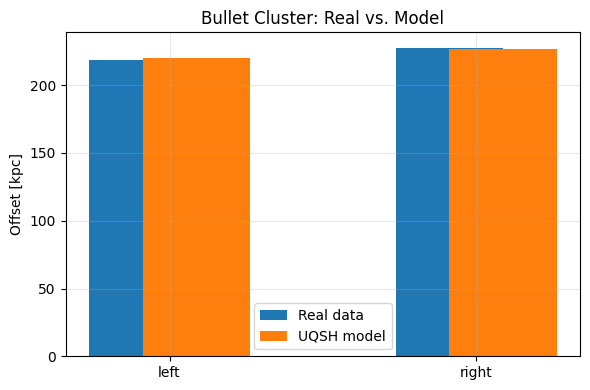

In [21]:
labels = ["left", "right"]
real_vals = [real_left_kpc, real_right_kpc]
model_vals = [model_left_kpc, model_right_kpc]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/4, real_vals, width, label="Real data")
plt.bar(x + width/4, model_vals, width, label="UQSH model")

plt.ylabel("Offset [kpc]")
plt.title("Bullet Cluster: Real vs. Model")
plt.xticks(x, labels)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_bullet_offsets.png", dpi=300, bbox_inches="tight")
plt.show()